In [2]:
import sys
sys.path.append("..")
from glob import glob
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns
from tqdm.auto import tqdm
from ridgeline_fn import ridgeline

import torch
from smiles_ae import (
    AutoencoderConfig, SmilesAutoencoder, SmilesTokenizer,
    SmilesDataset, make_dataloader, fit, maybe_extend_vocab,
    compute_reconstruction_errors,
)

Set paths to the pretrained model (in `MODEL_DIR`) and datafiles from the [Zenodo repository](https://zenodo.org/records/18846067). 

In [9]:
MODEL_DIR = "/home/pwalters/DATA/AE/code/runs/pretrain_cnn_lstm"
file_list = list(glob("/home/pwalters/DATA/JMM/data/split/*.csv"))

A simple function that does the following
1. Read the pretrained model
2. Read and update the associated tokenizer
3. Load the training and validation sets
4. Compute the reconstruction error for the test set
5. Compute the reconstruction error for the ood set

In [14]:
def test_ood(train_smiles, test_smiles, ood_smiles):
    tokenizer = SmilesTokenizer.load(f"{MODEL_DIR}/tokenizer.json")
    model = SmilesAutoencoder.load(f"{MODEL_DIR}/best.pt").to("cuda")

    maybe_extend_vocab(model, tokenizer, train_smiles)

    ft_ds  = SmilesDataset(train_smiles, tokenizer, max_len=128)
    val_ds = SmilesDataset(val_smiles,  tokenizer, max_len=128)

    ft_loader = make_dataloader(ft_ds, batch_size=64, pad_id=tokenizer.pad_id)
    val_loader = make_dataloader(val_ds, batch_size=64, pad_id=tokenizer.pad_id, shuffle=False)

    model_res = fit(model, ft_loader, val_loader, device="cuda", epochs=10, lr=2e-4,
        save_path="finetuned.pt",quiet=True)

    test_rows = compute_reconstruction_errors(
        model, tokenizer, test_smiles, device="cuda", decode=True,
    )
    test_df = pd.DataFrame(test_rows)
    test_df["dataset"] = "test"

    ood_rows = compute_reconstruction_errors(
        model, tokenizer, ood_smiles, device="cuda", decode=True,
    )
    ood_df = pd.DataFrame(ood_rows)
    ood_df["dataset"] = "ood"

    combo_df  =  pd.concat([test_df,ood_df])
    return combo_df

Loop over the papers and calcuate the OOD metrics for each molecule

In [15]:
df_list = []
for idx, file_name in enumerate(tqdm((file_list))):
    if file_name == '/home/pwalters/DATA/JMM/data/split/ChEMBL_33_split.csv':
        continue
    test_df = pd.read_csv(file_name)
    finetune_smiles = test_df.query("split == 'train'").smiles.values.tolist()
    train_smiles, val_smiles = train_test_split(finetune_smiles)

    test_smiles = test_df.query("split == 'test'").smiles.values.tolist()
    ood_smiles = test_df.query("split == 'ood'").smiles.values.tolist()

    result_df = test_ood(train_smiles, test_smiles, ood_smiles)
    result_df['file_name'] = file_name
    result_df['idx'] = idx
    df_list.append(result_df)

  0%|          | 0/34 [00:00<?, ?it/s]

Combine the results from all the trails into one dataframe. 

In [19]:
combo_df = pd.concat(df_list)

<Axes: xlabel='dataset', ylabel='reconstruction_error'>

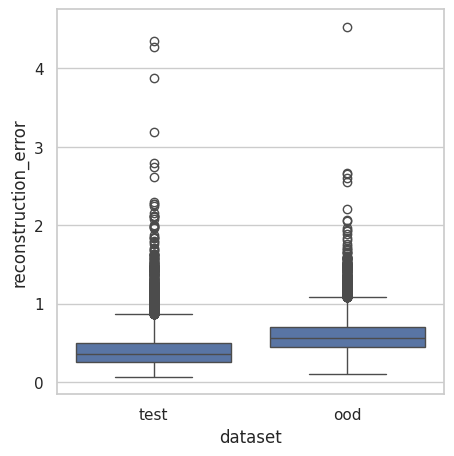

In [25]:
sns.set(rc={"figure.figsize":(5,5)})
sns.set(style="whitegrid")
sns.boxplot(x="dataset",y="reconstruction_error",data=combo_df)

(0.0, 2.0)

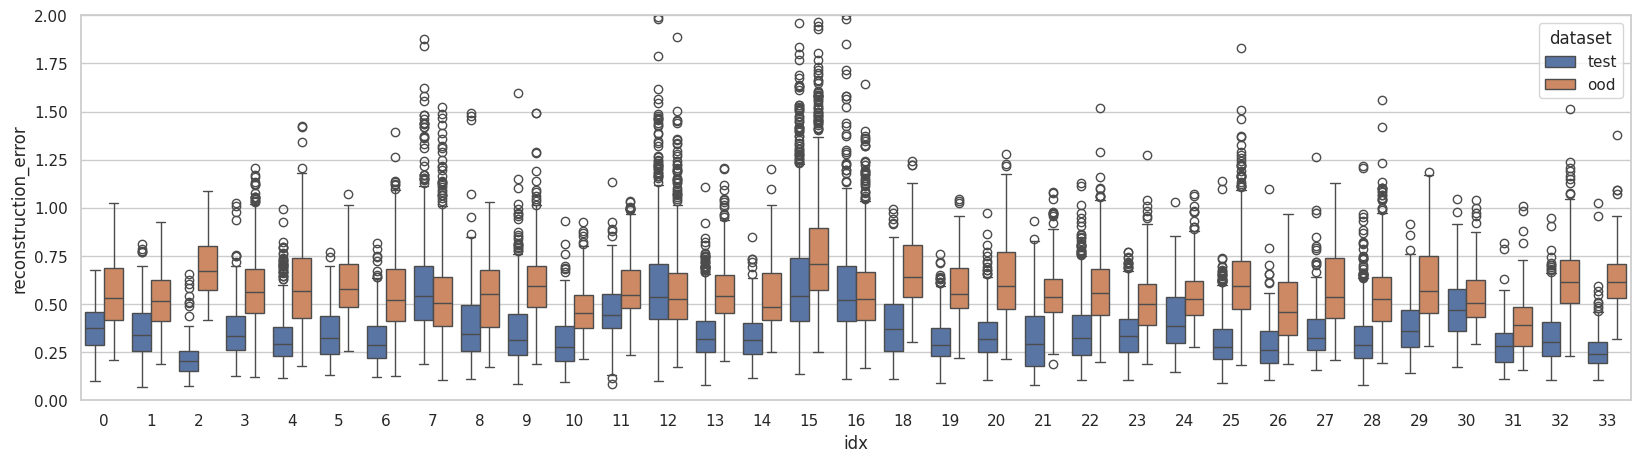

In [17]:
sns.set(rc={"figure.figsize":(20,5)})
sns.set(style="whitegrid")
ax = sns.boxplot(x="idx",y="reconstruction_error",data=combo_df,hue="dataset")
ax.set_ylim(0,2)

<Axes: xlabel='reconstruction_error'>

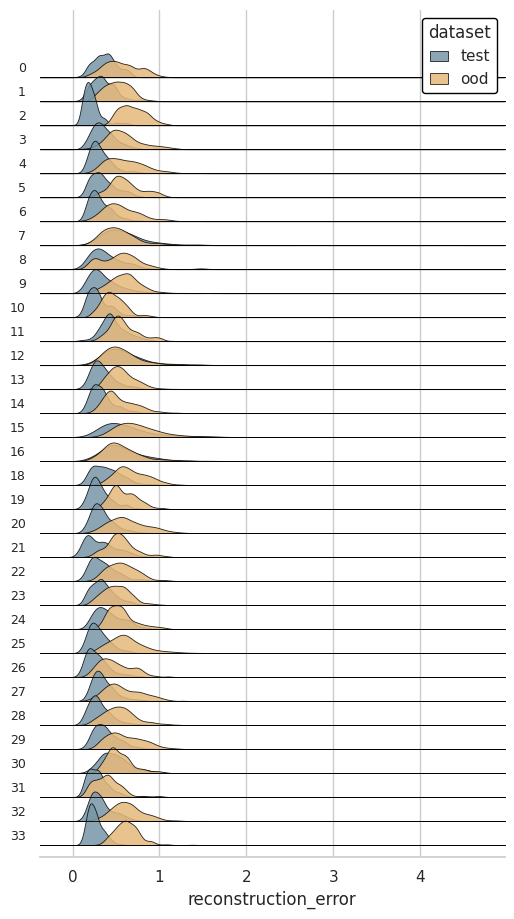

In [18]:
ridgeline(combo_df, row_id="idx",group="dataset",value="reconstruction_error",legend_kwargs={"edgecolor":"black"})